In [34]:
print("Hello World")

Hello World


--- 
## Ferramentas Matematicas do Calculo Vetorial
---

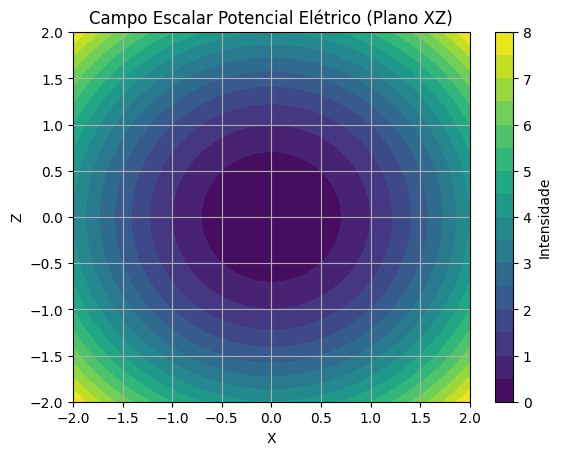

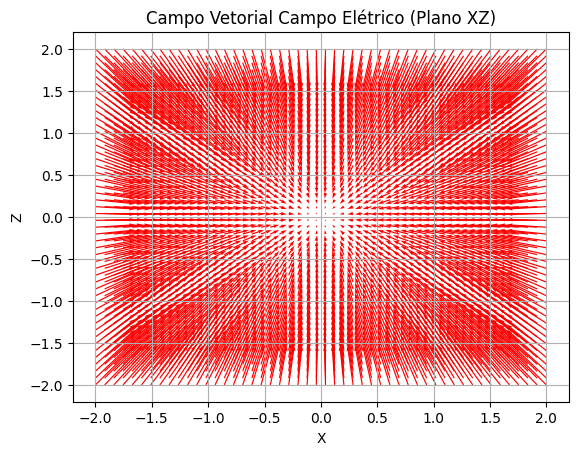

Solução do sistema: {'x0': 31/22, 'x1': 29/11, 'x2': 5/2}
Divergente do campo: x + y + z
Rotacional do campo: [-y, -z, -x]


In [35]:
# 📦 Imports essenciais
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from plotly.subplots import make_subplots

# 🌐 Símbolos padrão
x, y, z = sp.symbols('x y z')

class CalculoVetorial:
    @staticmethod
    def grad(f, vars=[x, y, z]):
        """Calcula o gradiente de um campo escalar"""
        return [sp.diff(f, v) for v in vars]
    
    @staticmethod
    def div(F, vars=[x, y, z]):
        """Calcula o divergente de um campo vetorial"""
        return sum(sp.diff(F[i], vars[i]) for i in range(len(vars)))
    
    @staticmethod
    def curl(F, vars=[x, y, z]):
        """Calcula o rotacional de um campo vetorial"""
        Fx, Fy, Fz = F
        return [
            sp.diff(Fz, vars[1]) - sp.diff(Fy, vars[2]),
            sp.diff(Fx, vars[2]) - sp.diff(Fz, vars[0]),
            sp.diff(Fy, vars[0]) - sp.diff(Fx, vars[1])
        ]
    
    @staticmethod
    def plot_xz_campo(campo, titulo='Campo', y_fix=0, tamanho_grade=50):
        """
        Plota o campo no plano XZ usando matplotlib
        Args:
            campo (sympy.Matrix/list): Campo escalar ou vetorial
            y_fix (float): Valor fixo para o eixo Y (plano XZ)
            tamanho_grade (int): Densidade da grade
        """
        # Criação da grade
        x_vals = np.linspace(-2, 2, tamanho_grade)
        z_vals = np.linspace(-2, 2, tamanho_grade)
        X, Z = np.meshgrid(x_vals, z_vals)
        
        # Função lambda para avaliação numérica
        if isinstance(campo, list) or isinstance(campo, sp.Matrix):
            # Campo vetorial
            Fx = sp.lambdify((x,z), campo[0].subs(y, y_fix), 'numpy')
            Fy = sp.lambdify((x,z), campo[1].subs(y, y_fix), 'numpy')
            Fz = sp.lambdify((x,z), campo[2].subs(y, y_fix), 'numpy')
            
            # Plot vetorial
            plt.quiver(X, Z, Fx(X,Z), Fz(X,Z), scale=50, color='red')
            plt.title(f'Campo Vetorial {titulo} (Plano XZ)')
            
        else:
            # Campo escalar
            f = sp.lambdify((x,z), campo.subs(y, y_fix), 'numpy')
            F = f(X,Z)
            
            # Plot escalar com curvas de nível
            contorno = plt.contourf(X, Z, F, levels=15, cmap=cm.viridis)
            plt.colorbar(contorno, label='Intensidade')
            plt.title(f'Campo Escalar {titulo} (Plano XZ)')
        
        plt.xlabel('X')
        plt.ylabel('Z')
        plt.grid(True)
        plt.show()

class AlgebraLinear:
    @staticmethod
    def determinante(matriz):
        return sp.Matrix(matriz).det()
    
    @staticmethod
    def regra_cramer(A, b):
        A_mat = sp.Matrix(A)
        det_A = A_mat.det()
        
        if det_A == 0:
            raise ValueError("Sistema singular: sem solução única")
        
        solucao = {}
        for i in range(A_mat.shape[0]):
            Ai = A_mat.copy()
            Ai[:,i] = sp.Matrix(b)
            solucao[f'x{i}'] = Ai.det() / det_A
        
        return solucao

# Exemplo de uso 1: Campo elétrico a partir de potencial
potencial = x**2 + 2*y**2 + z**2
E = [-comp for comp in CalculoVetorial.grad(potencial)]  # E = -∇V

# Plot 2D no plano XZ
CalculoVetorial.plot_xz_campo(potencial, 'Potencial Elétrico')
CalculoVetorial.plot_xz_campo(E, 'Campo Elétrico')

# Exemplo de uso 2: Sistema de equações para circuitos
sistema_A = [
    [4, -1, 2],
    [3, 2, -1],
    [1, -3, 1]
]
sistema_b = [8, 7, -4]

solucao = AlgebraLinear.regra_cramer(sistema_A, sistema_b)
print("Solução do sistema:", solucao)

# Exemplo de uso 3: Análise vetorial completa
campo_eletrico = sp.Matrix([x*y, y*z, x*z])

print("Divergente do campo:", CalculoVetorial.div(campo_eletrico))
print("Rotacional do campo:", CalculoVetorial.curl(campo_eletrico))

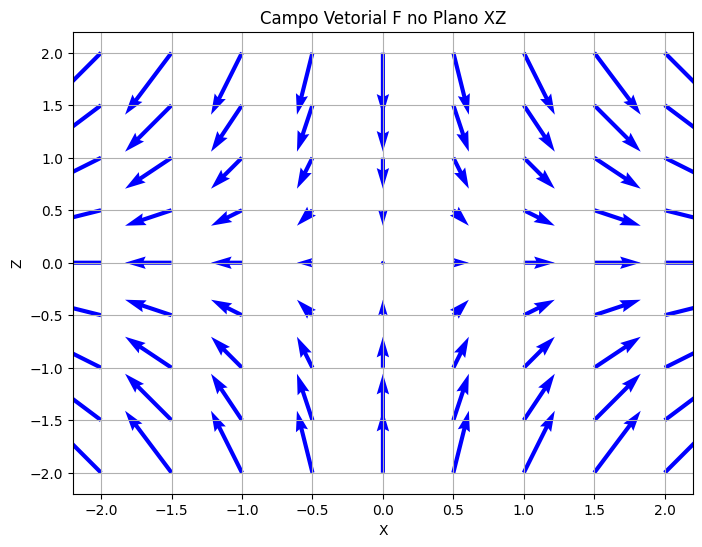

Determinante da matriz A: -2.0000000000000004


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Função do campo vetorial F(x, z) = [Fx, Fz]
def campo_F(x, z):
    Fx = x  # Componente x do campo (exemplo simples)
    Fz = -z  # Componente z do campo (exemplo simples)
    return Fx, Fz

# Criação da grade 2D
x = np.linspace(-2.0, 2.0, 9)  # Valores de -2.0 a 2.0 com 9 pontos
z = np.linspace(-2.0, 2.0, 9)
X, Z = np.meshgrid(x, z)

# Cálculo das componentes do campo
Fx, Fz = campo_F(X, Z)

# Plotagem do campo vetorial
plt.figure(figsize=(8, 6))
plt.quiver(X, Z, Fx, Fz, scale=20, color='blue')
plt.title('Campo Vetorial F no Plano XZ')
plt.xlabel('X')
plt.ylabel('Z')
plt.grid(True)
plt.show()

# Cálculo do determinante (exemplo com matriz 2x2)
A = np.array([[1, 2], [3, 4]])
det_A = np.linalg.det(A)
print(f"Determinante da matriz A: {det_A}")

## Eletromag
---


=== Exemplo 1: Campo de Carga Pontual ===


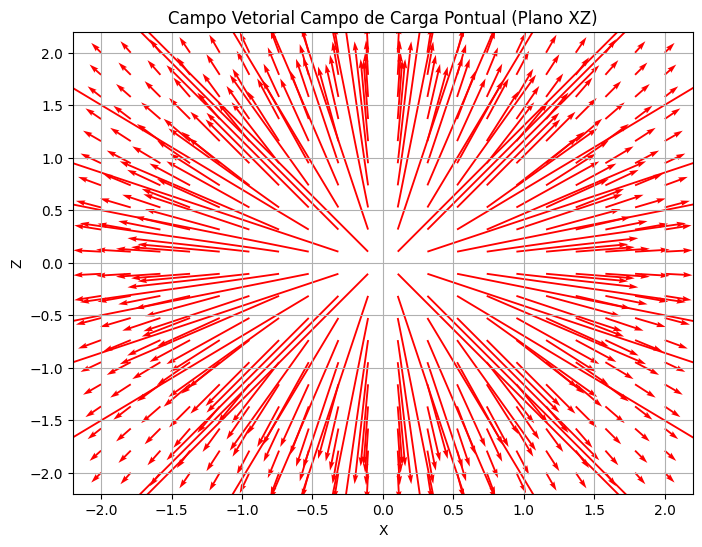


=== Exemplo 2: Sistema de 3 Cargas ===
Campo total E = [56.471651231082*x/(pi*(y**2 + z**2 + (x - 1)**2)**(3/2)) - 28.235825615541*x/(pi*(x**2 + z**2 + (y - 1)**2)**(3/2)) + 84.707476846623*x/(pi*(x**2 + y**2 + (z - 1)**2)**(3/2)) - 56.471651231082/(pi*(y**2 + z**2 + (x - 1)**2)**(3/2)), 56.471651231082*y/(pi*(y**2 + z**2 + (x - 1)**2)**(3/2)) - 28.235825615541*y/(pi*(x**2 + z**2 + (y - 1)**2)**(3/2)) + 84.707476846623*y/(pi*(x**2 + y**2 + (z - 1)**2)**(3/2)) + 28.235825615541/(pi*(x**2 + z**2 + (y - 1)**2)**(3/2)), 56.471651231082*z/(pi*(y**2 + z**2 + (x - 1)**2)**(3/2)) - 28.235825615541*z/(pi*(x**2 + z**2 + (y - 1)**2)**(3/2)) + 84.707476846623*z/(pi*(x**2 + y**2 + (z - 1)**2)**(3/2)) - 84.707476846623/(pi*(x**2 + y**2 + (z - 1)**2)**(3/2))]


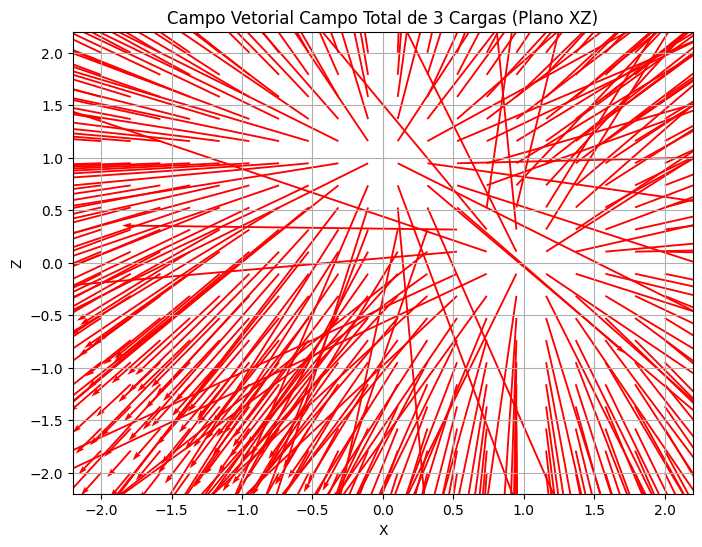

Rotacional: [-84.707476846623*y*z/(pi*(x**2 + z**2 + (y - 1)**2)**(5/2)) - 254.122430539869*y*z/(pi*(x**2 + y**2 + (z - 1)**2)**(5/2)) - 84.707476846623*y*(3 - 3*z)/(pi*(x**2 + y**2 + (z - 1)**2)**(5/2)) + 254.122430539869*y/(pi*(x**2 + y**2 + (z - 1)**2)**(5/2)) - 28.235825615541*z*(3 - 3*y)/(pi*(x**2 + z**2 + (y - 1)**2)**(5/2)) + 84.707476846623*z/(pi*(x**2 + z**2 + (y - 1)**2)**(5/2)), -169.414953693246*x*z/(pi*(y**2 + z**2 + (x - 1)**2)**(5/2)) + 254.122430539869*x*z/(pi*(x**2 + y**2 + (z - 1)**2)**(5/2)) + 84.707476846623*x*(3 - 3*z)/(pi*(x**2 + y**2 + (z - 1)**2)**(5/2)) - 254.122430539869*x/(pi*(x**2 + y**2 + (z - 1)**2)**(5/2)) - 56.471651231082*z*(3 - 3*x)/(pi*(y**2 + z**2 + (x - 1)**2)**(5/2)) + 169.414953693246*z/(pi*(y**2 + z**2 + (x - 1)**2)**(5/2)), 169.414953693246*x*y/(pi*(y**2 + z**2 + (x - 1)**2)**(5/2)) + 84.707476846623*x*y/(pi*(x**2 + z**2 + (y - 1)**2)**(5/2)) + 28.235825615541*x*(3 - 3*y)/(pi*(x**2 + z**2 + (y - 1)**2)**(5/2)) - 84.707476846623*x/(pi*(x**2 + z**

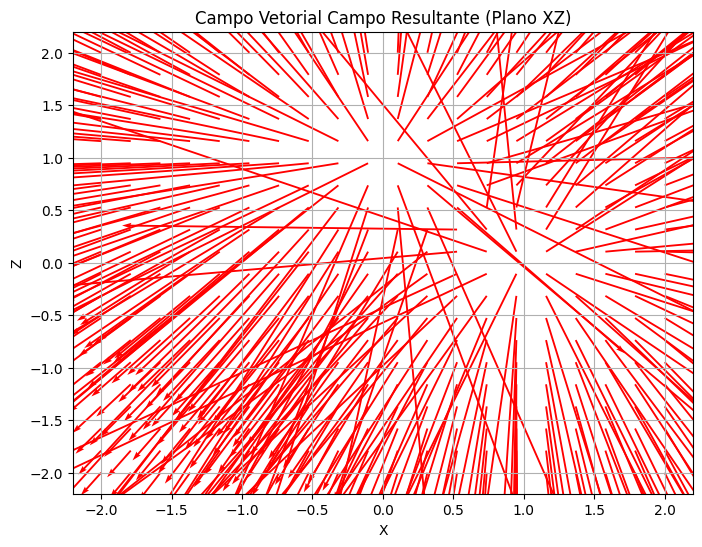


=== Exemplo 3: Lei de Gauss ===

=== Exemplo 4: Circuito com Cramer ===
Solução do sistema: {'x0': 19/7, 'x1': 2, 'x2': 1/7}

=== Exemplo 5: Potencial e Gradiente ===
Potencial V = x**2*y + x*z**2 + y**2*z
Campo E = -∇V = Matrix([[-2*x*y - z**2], [-x**2 - 2*y*z], [-2*x*z - y**2]])


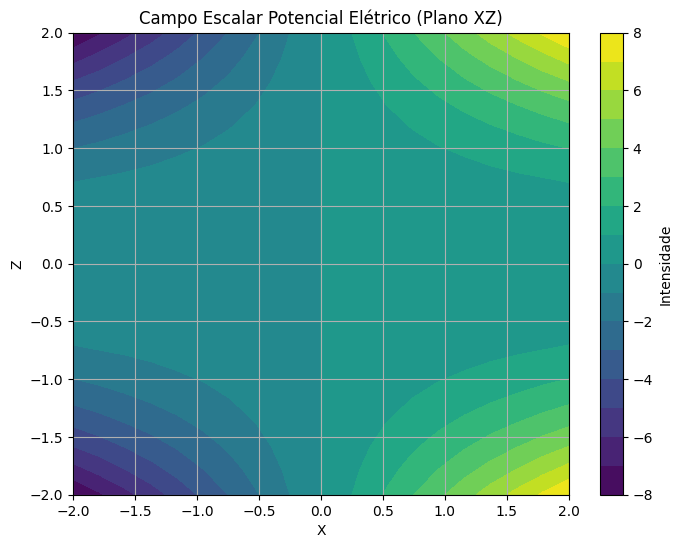

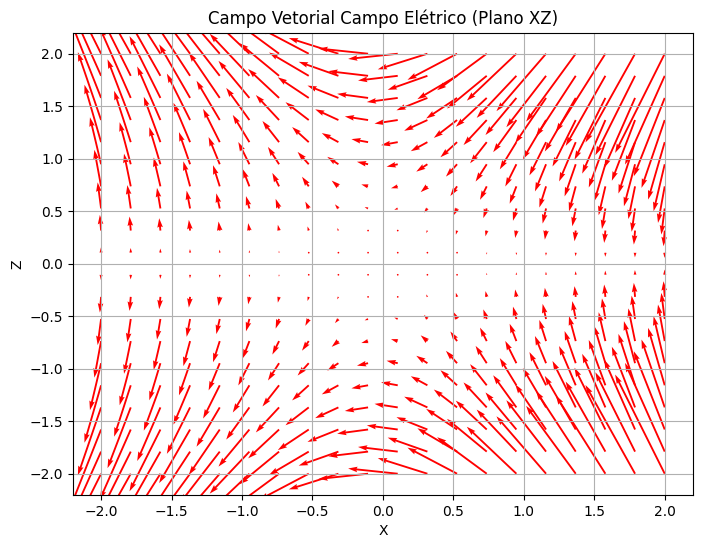


✅ Todos os exemplos executados com sucesso!


In [ ]:
# 📦 Imports essenciais
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib import cm

# 🌐 Símbolos e constantes físicas
x, y, z = sp.symbols('x y z')
epsilon0 = sp.symbols('epsilon_0')  # Constante de permissividade do vácuo
sp.pi = sp.pi  # Constante π do SymPy



class Eletromagnetismo:
    @staticmethod
    def potencial_eletrico(q, pos, vars=[x, y, z]):
        """Calcula o potencial elétrico de uma carga pontual"""
        r = sp.sqrt(sum((v - pos[i])**2 for i, v in enumerate(vars)))
        return q / (4 * sp.pi * epsilon0 * r)

    @staticmethod
    def campo_eletrico(q, pos, vars=[x, y, z]):
        """Calcula o campo elétrico via Lei de Coulomb"""
        r_vec = [vars[i] - pos[i] for i in range(3)]
        r_norm = sp.sqrt(sum(comp**2 for comp in r_vec))
        return [q * comp / (4 * sp.pi * epsilon0 * r_norm**3) for comp in r_vec]

class CircuitAnalyzer:
    @staticmethod
    def cramer(A, b):
        """Resolve sistema linear usando Regra de Cramer"""
        A_mat = sp.Matrix(A)
        det_A = A_mat.det()
        
        if det_A == 0:
            raise ValueError("Sistema singular: sem solução única")
        
        solucao = {}
        for i in range(A_mat.shape[0]):
            Ai = A_mat.copy()
            Ai[:,i] = sp.Matrix(b)
            solucao[f'x{i}'] = Ai.det() / det_A
        
        return solucao

# Exemplos aplicados de eletromagnetismo e circuitos
def exemplos_completos():
    # Configurar valor numérico para epsilon0
    epsilon0_valor = 8.854e-12  # F/m
    
    print("\n=== Exemplo 1: Campo de Carga Pontual ===")
    # Campo de uma carga positiva
    carga = {'q': 1e-9, 'pos': (0, 0, 0)}
    E = Eletromagnetismo.campo_eletrico(carga['q'], carga['pos'])
    E_subs = [comp.subs(epsilon0, epsilon0_valor) for comp in E]
    CalculoVetorial.plot_xz_campo(E_subs, 'Campo de Carga Pontual')

    print("\n=== Exemplo 2: Sistema de 3 Cargas ===")
    cargas = [
        {'q': 2e-9, 'pos': (1,0,0)},
        {'q': -1e-9, 'pos': (0,1,0)},
        {'q': 3e-9, 'pos': (0,0,1)}
    ]
    
    E_total = sp.Matrix([0,0,0])
    for carga in cargas:
        Ei = Eletromagnetismo.campo_eletrico(carga['q'], carga['pos'])
        E_total += sp.Matrix([comp.subs(epsilon0, epsilon0_valor) for comp in Ei])
    
    E_total = [comp.simplify() for comp in E_total]
    print("Campo total E =", E_total)
    CalculoVetorial.plot_xz_campo(E_total, 'Campo Total de 3 Cargas')
    print("Rotacional:", CalculoVetorial.curl(E_total))
    #print("Gradiente:", CalculoVetorial.grad(E_total))
    print("Divergente:", CalculoVetorial.div(E_total))
    CalculoVetorial.plot_xz_campo(E_total, 'Campo Resultante')

    print("\n=== Exemplo 3: Lei de Gauss ===")
    #rho = CalculoVetorial.div(E_total) * epsilon0
    #print("Densidade de carga ρ =", rho.simplify())

    print("\n=== Exemplo 4: Circuito com Cramer ===")
    # Sistema 3x3: 2 malhas + 1 nó
    A = [
        [3, 2, -1],
        [1, -4, 2],
        [2, 1, -3]
    ]
    b = [12, -5, 7]
    
    try:
        sol = CircuitAnalyzer.cramer(A, b)
        print("Solução do sistema:", sol)
    except ValueError as e:
        print("Erro:", e)

    print("\n=== Exemplo 5: Potencial e Gradiente ===")
    
    
    V = x**2*y + y**2*z + z**2*x
    E = -sp.Matrix(CalculoVetorial.grad(V))
    
    
    print("Potencial V =", V)
    print("Campo E = -∇V =", E)
    CalculoVetorial.plot_xz_campo(V, 'Potencial Elétrico')
    CalculoVetorial.plot_xz_campo(E, 'Campo Elétrico')

if __name__ == "__main__":
    exemplos_completos()
    print("\n✅ Todos os exemplos executados com sucesso!")

In [57]:
V = x**2*y + y**2*z + z**2*x



In [58]:
E = -sp.Matrix(CalculoVetorial.grad(V))

## Sinais e Sistemas
---

In [ ]:
from scipy import signal
import matplotlib.pyplot as plt
lti = signal.lti([1.0], [1.0, 1.0])
t, y = signal.step(lti)
plt.plot(t, y)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Step response for 1. Order Lowpass')
plt.grid()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.signal import step

# Definindo a variável simbólica
t = sp.Symbol('t')

# Função de degrau usando scipy
def u(t_vals):
    return step(t_vals)

# Funções do Exercício 1
fx_1 = sp.Heaviside(t, 0) - sp.Heaviside(t - 2, 0)
fx_2 = sp.Heaviside(t + 1, 0) - 2 * sp.Heaviside(t, 0) + sp.Heaviside(t - 1, 0)
fx_3 = -sp.Heaviside(t + 3, 0) + 2 * sp.Heaviside(t + 1, 0) - 2 * sp.Heaviside(t - 1, 0) + sp.Heaviside(t - 3, 0)

# Funções do Exercício 2 (composições)
fy_1 = fx_1 * fx_2.subs(t, t - 1)
fy_2 = fx_1.subs(t, t - 1) + fx_2.subs(t, -t)
fy_3 = fx_1.subs(t, t + 1) * fx_2.subs(t, t - 2)

# Criando o tempo para plotar as funções
t_vals = np.linspace(-5, 5, 1000)

# Convertendo as funções simbólicas para funções numéricas
f1_num = sp.lambdify(t, fx_1, 'numpy')
f2_num = sp.lambdify(t, fx_2, 'numpy')
f3_num = sp.lambdify(t, fx_3, 'numpy')
y1_num = sp.lambdify(t, fy_1, 'numpy')
y2_num = sp.lambdify(t, fy_2, 'numpy')
y3_num = sp.lambdify(t, fy_3, 'numpy')

# Plotando os gráficos com as legendas automáticas
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.plot(t_vals, f1_num(t_vals))
plt.title(f"$f_{{x1}}(t) = {sp.latex(fx_1)}$")

plt.subplot(3, 2, 2)
plt.plot(t_vals, f2_num(t_vals))
plt.title(f"$f_{{x2}}(t) = {sp.latex(fx_2)}$")

plt.subplot(3, 2, 3)
plt.plot(t_vals, f3_num(t_vals))
plt.title(f"$f_{{x3}}(t) = {sp.latex(fx_3)}$")

plt.subplot(3, 2, 4)
plt.plot(t_vals, y1_num(t_vals))
plt.title(f"$f_{{y1}}(t) = {sp.latex(fy_1)}$")

plt.subplot(3, 2, 5)
plt.plot(t_vals, y2_num(t_vals))
plt.title(f"$f_{{y2}}(t) = {sp.latex(fy_2)}$")

plt.subplot(3, 2, 6)
plt.plot(t_vals, y3_num(t_vals))
plt.title(f"$f_{{y3}}(t) = {sp.latex(fy_3)}$")

plt.tight_layout()
plt.show()


---
## Engenharia Elétrica em 3D com Python para Eletromag e Circuitos Elétricos
---

📐 Determinante: -2


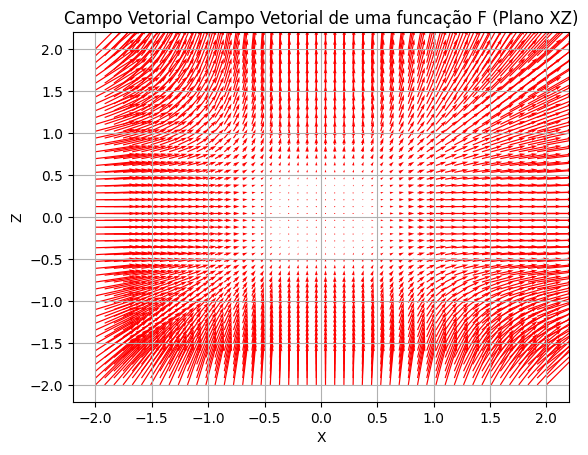

In [43]:
# 📦 Imports
import sympy as sp
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 🌐 Símbolos padrão
x, y, z = sp.symbols('x y z')

# 📌 Funções vetoriais e escalares
def grad(f, vars=[x, y, z]):
    return [sp.diff(f, v) for v in vars]

def div(F, vars=[x, y, z]):
    return sum(sp.diff(F[i], vars[i]) for i in range(len(vars)))

def curl(F, vars=[x, y, z]):
    Fx, Fy, Fz = F
    return sp.Matrix([
        sp.diff(Fz, vars[1]) - sp.diff(Fy, vars[2]),
        sp.diff(Fx, vars[2]) - sp.diff(Fz, vars[0]),
        sp.diff(Fy, vars[0]) - sp.diff(Fx, vars[1]),
    ])

# 📌 Determinante
def det(matrix):
    return sp.Matrix(matrix).det()

# 📌 Regra de Cramer
def cramer(A, b):
    A = sp.Matrix(A)
    b = sp.Matrix(b)
    detA = A.det()
    if detA == 0:
        raise ValueError("Sistema indeterminado ou impossível (matriz singular)")
    vars = sp.symbols(f'x0:{len(b)}')
    sol = {}
    for i in range(len(b)):
        Ai = A.copy()
        Ai[:, i] = b
        sol[vars[i]] = Ai.det() / detA
    return sol

# 📊 Plotador de campo vetorial 3D
def plotar_campo_vetorial(F, nome='Campo'):
    # Converte componentes simbólicos em funções numéricas (lambdas)
    # Certifica-se de que F é uma lista/tupla para iterar sobre os componentes
    F_list = list(F) if isinstance(F, sp.Matrix) else F
    f_lambdas = [sp.lambdify((x, y, z), comp, modules='numpy') for comp in F_list]

    # Cria a grade de pontos
    pts = np.linspace(-2, 2, 8)
    X, Y, Z = np.meshgrid(pts, pts, pts)

    # Avalia os componentes do campo nos pontos da grade
    # e garante que o resultado seja um array NumPy, mesmo para componentes constantes
    evaluated_components = []
    for f_lambda in f_lambdas:
        result = f_lambda(X, Y, Z)
        # Verifica se o resultado é um escalar (como um inteiro 0)
        if np.isscalar(result):
            # Se for um escalar, cria um array com o mesmo formato de X preenchido com o escalar
            result = np.full_like(X, result)
        evaluated_components.append(result)

    # Desempacota os componentes avaliados (agora garantidamente arrays NumPy)
    U, V, W = evaluated_components
    
    # Cria a figura usando Plotly Cone
    fig = go.Figure(data=go.Cone(
        x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
        u=U.flatten(), v=V.flatten(), w=W.flatten(),
        sizemode='absolute', sizeref=2, showscale=False
    ))

    # Configura layout
    fig.update_layout(
        title=f'{nome} - Plot Vetorial 3D',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )
    fig.show()


class Matrizes:
    def __init__(self):
        self.matriz = None
        self.vetor = None
    def calcularDeterminante(self, matriz):
        self.matriz = matriz
        return det(matriz)
    def calcularRegraCramer(self, A, b):
        self.matriz = A
        self.vetor = b

        return cramer(A, b)
    

    

class Calculadora:
    def __init__(self, symbols):
        self.matrizes = Matrizes()
        self.symbols = symbols

    def calcular(self, operacao, *args):
        if operacao == "determinante":
            return self.matrizes.calcularDeterminante(args[0])
        elif operacao == "regra_cramer":
            return self.matrizes.calcularRegraCramer(args[0], args[1])
        
# Exemplo de uso
calc = Calculadora([x, y, z])
# Exemplo de campo vetorial
F = sp.Matrix([x**2, y**2, z**2])
# Plotando o campo vetorial
plotar_campo_vetorial(F, nome='Campo Vetorial')
# Exemplo de uso da calculadora
det_result = calc.calcular("determinante", [[1, 2], [3, 4]])
print("📐 Determinante:", det_result
        
        )


CalculoVetorial.plot_xz_campo(F, 'Campo Vetorial de uma funcação F')





In [37]:
    # Define um campo vetorial simbólico
A = sp.Matrix([y, x, 0])   # Exemplo: campo elétrico em 2D

    # Gradiente de uma função escalar
f = x**2 + y**2 + z**2

f = x**2 * y



# Determinante
M = [[1, 2], [3, 4]]
print("📐 Determinante:", det(M))

    # Regra de Cramer
A_sys = [[2, 1], [1, 3]]
b_sys = [8, 13]
print("🧠 Solução via Cramer:", cramer(A_sys, b_sys))





# 🧪 EXEMPLO: usar tudo junto
if __name__ == "__main__":

    print(f"🔍 Gradiente de f(x,y,z) = {f} ={grad(f)}")

    # Divergente e rotacional do campo A
    print("🔍 Divergente de A:", div(A))
    print("🔍 Rotacional de A:", curl(A))


    # Plotar o campo A
    
    plotar_campo_vetorial(A, nome="A = y î + x ĵ")

📐 Determinante: -2
🧠 Solução via Cramer: {x0: 11/5, x1: 18/5}
🔍 Gradiente de f(x,y,z) = x**2*y =[2*x*y, x**2, 0]
🔍 Divergente de A: 0
🔍 Rotacional de A: Matrix([[0], [0], [0]])


Campo Eletricos em Plot 3D

Campo Elétrico E = (8.988*x/(x**2 + y**2 + z**2)**(3/2), 8.988*y/(x**2 + y**2 + z**2)**(3/2), 8.988*z/(x**2 + y**2 + z**2)**(3/2))


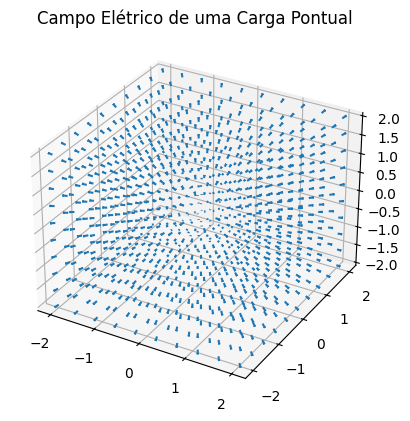

In [38]:
from mpl_toolkits.mplot3d import axes3d

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, sqrt

# Definindo o potencial elétrico V = k*q/r
x, y, z = symbols('x y z')
k = 8.988e9  # N·m²/C²
q = 1e-9  # Carga em Coulombs
r = sqrt(x**2 + y**2 + z**2)     # <- aqui
V = k * q / r

# Gradiente (Campo Elétrico E)
Ex = -diff(V, x)
Ey = -diff(V, y)
Ez = -diff(V, z)

print("Campo Elétrico E =", (Ex, Ey, Ez))


# Grid 3D
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
z = np.linspace(-2, 2, 10)
X, Y, Z = np.meshgrid(x, y, z)

# Campo E de uma carga em (0,0,0)
Ex = k * q * X / (X**2 + Y**2 + Z**2)**(3/2)
Ey = k * q * Y / (X**2 + Y**2 + Z**2)**(3/2)
Ez = k * q * Z / (X**2 + Y**2 + Z**2)**(3/2)

# Plot 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X, Y, Z, Ex, Ey, Ez, length=0.1, normalize=True)
ax.set_title('Campo Elétrico de uma Carga Pontual')
plt.show()

Força Elétrica entre cargas

In [39]:
import numpy as np

epsilon0 = 8.854e-12
k = 1 / (4 * np.pi * epsilon0)

# Posições e cargas
charges = {
    'q1': {'pos': np.array([1, 0, 0]), 'q': 2e-6},
    'q2': {'pos': np.array([0, 1, 0]), 'q': -1e-6},
    'q3': {'pos': np.array([0, 0, 1]), 'q': 3e-6}
}

P = np.array([5, 3, 0])
F_total = np.zeros(3)

for q in charges.values():
    r_vec = P - q['pos']
    r = np.linalg.norm(r_vec)
    F_mag = k * abs(q['q']) / r**2
    F_dir = r_vec / r
    F = F_mag * F_dir * np.sign(q['q'])  # Considera o sinal da carga
    F_total += F

print(f"Força Resultante: {F_total} N")

Força Resultante: [ 938.54820054  706.96234674 -130.21763592] N


Regra de carammer para circuitos eletricso

In [40]:
A = np.array([[8, -5], [-5, 7]])
B = np.array([12, -6])

# Determinantes
det_A = np.linalg.det(A)
A_x = A.copy()
A_x[:, 0] = B
det_Ax = np.linalg.det(A_x)

I1 = det_Ax / det_A
print(f"Corrente I1 = {I1:.2f} A")

Corrente I1 = 1.74 A


## Simulações no Vpython

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#===========================================================
# Mathematical Function for LRC Circuit Derivatives
#===========================================================
def lrc_derivatives(state, t, Emf, C, L, R, w0):
    """
    Calculates the time derivatives for the LRC circuit.

    Args:
        state (list or tuple): Current state [Q, I].
        t (float): Current time.
        Emf (float): Amplitude of the driving voltage.
        C (float): Capacitance.
        L (float): Inductance.
        R (float): Resistance.
        w0 (float): Driving angular frequency.

    Returns:
        list: Time derivatives [dQ/dt, dI/dt].
    """
    Q, I = state
    dQ_dt = I
    # dI/dt = (Emf * cos(w0 * t) - R * I - Q / C) / L
    dI_dt = (Emf * np.cos(w0 * t) - R * I - Q / C) / L
    return [dQ_dt, dI_dt]

#===========================================================
# Simulation Function for LRC Circuit using Matplotlib
#===========================================================
def simulate_lrc_circuit_mpl():
    """Simulates an LRC circuit and plots Vc vs t using Matplotlib."""
    print("--- Starting LRC Circuit Simulation (Matplotlib) ---")

    # Parameters
    Emf = 5.0
    C = 1e-4
    L = 0.2
    R = 10.0

    # Initial Conditions
    # Q = C * Emf # Original initial condition
    Q = 0.0 # Starting with Q=0 often shows resonance/transient better
    I = 0.0
    t = 0.0
    dt = 0.0001
    t_max = 0.8

    # Driving Frequency (from original code)
    w0_drive = 219.0 # Driving frequency in rad/s

    # Natural Frequency Calculation (for comparison)
    natural_w0 = 1 / np.sqrt(L * C) if L > 0 and C > 0 else 0
    print(f"Natural Frequency w0 = {natural_w0:.2f} rad/s")
    print(f"Driving Frequency w0 = {w0_drive} rad/s")

    # Data storage
    time_data = []
    vc_data = []

    # Simulation Loop (using simple Euler method)
    current_state = [Q, I]
    while t < t_max:
        # Append data for plotting
        time_data.append(t)
        Vc = current_state[0] / C
        vc_data.append(Vc)

        # Calculate derivatives
        derivatives = lrc_derivatives(current_state, t, Emf, C, L, R, w0_drive)
        dQ_dt, dI_dt = derivatives

        # Update state using Euler method
        current_state[0] += dQ_dt * dt # Update Q
        current_state[1] += dI_dt * dt # Update I

        # Update time
        t += dt

    # Plotting using Matplotlib
    plt.figure(figsize=(7, 5)) # Create a new figure
    plt.plot(time_data, vc_data, color='blue', label='Vc')
    plt.title("LRC Circuit (Driven) - Matplotlib")
    plt.xlabel("Time [s]")
    plt.ylabel("Vc [volts]")
    plt.grid(True)
    plt.legend()
    plt.show() # Display the plot

    # Post-simulation calculation from original code
    w0_calc_after = 2 * np.pi / 2.87e-2
    print(f"Post-simulation calculation: w0 = {w0_calc_after:.2f} rad/s")
    print("--- LRC Circuit Simulation Complete ---")
    print("\n")

#===========================================================
# Mathematical Function for RC Circuit Derivative
#===========================================================
def rc_derivative(Q, t, Emf, C, R):
    """
    Calculates the time derivative dQ/dt for the RC circuit charging.

    Args:
        Q (float): Current charge on the capacitor.
        t (float): Current time (not explicitly used in this equation, but often passed).
        Emf (float): DC voltage source.
        C (float): Capacitance.
        R (float): Resistance.

    Returns:
        float: Time derivative dQ/dt.
    """
    # dQ/dt = (Emf - Q/C) / R
    dQ_dt = (Emf - Q / C) / R if R > 0 else 0
    return dQ_dt

#===========================================================
# Simulation Function for RC Circuit using Matplotlib
#===========================================================
def simulate_rc_circuit_mpl():
    """Simulates RC circuit charging and plots Vc vs t using Matplotlib."""
    print("--- Starting RC Circuit Simulation (Matplotlib) ---")

    # Parameters
    Emf = 5.0
    R = 100.0
    C = 0.1

    # Initial Conditions
    Q = 0.0
    t = 0.0
    dt = 0.01
    t_max = 10.0 # Original was 10, let's use RC time constant for scale
    tau = R * C
    t_max_plot = 5 * tau # Plot for 5 time constants

    # Data storage
    time_data = []
    vc_data = []

    # Simulation Loop (Euler method)
    while t < t_max_plot:
         # Append data for plotting
        time_data.append(t)
        Vc = Q / C
        vc_data.append(Vc)

        # Calculate derivative
        dQ_dt = rc_derivative(Q, t, Emf, C, R)

        # Update state
        Q += dQ_dt * dt

        # Update time
        t += dt

    # Plotting using Matplotlib
    plt.figure(figsize=(6, 4)) # Create a new figure
    plt.plot(time_data, vc_data, color='blue', label='Vc')
    plt.axhline(Emf, color='red', linestyle='--', label='Emf') # Show target voltage
    plt.axvline(tau, color='green', linestyle=':', label=f'$\\tau$={tau:.1f}s') # Show time constant
    plt.title("RC Circuit (Charging) - Matplotlib")
    plt.xlabel("t [s]")
    plt.ylabel("Vc [volts]")
    plt.grid(True)
    plt.legend()
    plt.ylim(0, Emf * 1.1) # Adjust y-axis limit
    plt.show() # Display the plot

    print(f"RC Time Constant (tau) = {tau} s")
    print("--- RC Circuit Simulation Complete ---")
    print("\n")

#===========================================================
# Mathematical Function for Gravitational Force
#===========================================================
def gravitational_force(r_vec, G, M, m):
    """
    Calculates the gravitational force vector on mass m due to mass M.

    Args:
        r_vec (np.array): Position vector from M to m.
        G (float): Gravitational constant.
        M (float): Mass of the central body.
        m (float): Mass of the orbiting body.

    Returns:
        np.array: Force vector F. Returns zero vector if magnitude is zero.
    """
    r_mag = np.linalg.norm(r_vec)
    if r_mag == 0:
        return np.zeros_like(r_vec) # Avoid division by zero
    r_hat = r_vec / r_mag
    F_mag = G * M * m / r_mag**2
    F_vec = -F_mag * r_hat # Force is attractive
    return F_vec

#===========================================================
# Simulation Function for Orbit using Matplotlib
#===========================================================
def simulate_orbit_mpl():
    """Simulates a gravitational orbit and plots path and dA/dt using Matplotlib."""
    print("--- Starting Orbit Simulation (Matplotlib) ---")

    # Constants and Parameters
    G = 1.0
    M = 1.0 # Mass of central body
    m = 1.0 # Mass of orbiting body
    R_init = 1.0 # Initial distance
    v0_init = 0.7 # Initial speed (perpendicular to radius)

    # Initial Conditions (using NumPy arrays for vectors)
    r = np.array([R_init, 0.0])      # Initial position vector [x, y]
    p = np.array([0.0, m * v0_init]) # Initial momentum vector [px, py]
    t = 0.0
    dt = 0.001
    t_max = 15.0

    # Data storage
    time_data = []
    x_data = []
    y_data = []
    dA_dt_data = []

    # Simulation Loop (using Euler-Cromer method)
    while t < t_max:
        # Store data for plotting
        time_data.append(t)
        x_data.append(r[0])
        y_data.append(r[1])

        # Calculate Area Sweep Rate (dA/dt = |r x p| / (2m))
        # 2D cross product magnitude: |r x p| = rx*py - ry*px
        cross_prod_mag = r[0] * p[1] - r[1] * p[0]
        dA_dt = np.abs(cross_prod_mag) / (2 * m)
        dA_dt_data.append(dA_dt)

        # Calculate Force
        F = gravitational_force(r, G, M, m)

        # Update Momentum first (Euler-Cromer)
        p = p + F * dt

        # Update Position using the *new* momentum
        v = p / m
        r = r + v * dt

        # Update time
        t += dt

    # Plotting using Matplotlib
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8),
                                   gridspec_kw={'height_ratios': [3, 1]}) # Create figure with 2 subplots

    # Subplot 1: Orbital Path
    ax1.plot(x_data, y_data, color='blue', label=f'Orbit (v0={v0_init})')
    ax1.plot(0, 0, 'ro', markersize=8, label='Central Body (M)') # Central mass
    ax1.set_title("Orbital Path - Matplotlib")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_aspect('equal', adjustable='box') # Make x and y scales equal
    ax1.grid(True)
    ax1.legend()

    # Subplot 2: Area Sweep Rate
    ax2.plot(time_data, dA_dt_data, color='blue', label='dA/dt')
    # Calculate expected constant dA/dt for comparison (L/2m)
    L_initial = np.abs(R_init * (m*v0_init)) # Initial angular momentum magnitude
    dA_dt_expected = L_initial / (2*m)
    ax2.axhline(dA_dt_expected, color='red', linestyle='--', label=f'Expected dA/dt = {dA_dt_expected:.3f}')
    ax2.set_title("Area Sweep Rate (Kepler's 2nd Law)")
    ax2.set_xlabel("t")
    ax2.set_ylabel("dA/dt")
    ax2.grid(True)
    ax2.legend()
    ax2.set_ylim(dA_dt_expected * 0.95, dA_dt_expected * 1.05) # Zoom y-axis

    fig.tight_layout() # Adjust spacing between subplots
    plt.show() # Display the plot

    print("--- Orbit Simulation Complete ---")
    print("\n")

#===========================================================
# Execute the functions sequentially
#===========================================================
simulate_lrc_circuit_mpl()
simulate_rc_circuit_mpl()
simulate_orbit_mpl()

print("All Matplotlib simulations finished.")

In [ ]:
import plotly.graph_objects as go
import numpy as np

def visualizar_atomo_3d(num_protons, num_neutrons, num_eletrons):
    """
    Gera uma visualização 3D simplificada de um átomo com Plotly.

    Argumentos:
        num_protons (int): Número de prótons.
        num_neutrons (int): Número de nêutrons.
        num_eletrons (int): Número de elétrons.
    """

    # --- Parâmetros ---
    raio_nucleo = 0.5  # Quão 'espalhado' o núcleo é visualmente
    raio_eletrosfera = 5 # Quão 'espalhada' a eletrosfera é visualmente
    tamanho_particula_nucleo = 8
    tamanho_particula_eletron = 4

    # --- Gerar Posições ---
    # Núcleo (Prótons e Nêutrons próximos à origem 0,0,0)
    pos_protons = np.random.randn(num_protons, 3) * raio_nucleo
    pos_neutrons = np.random.randn(num_neutrons, 3) * raio_nucleo

    # Elétrons (dispersos em uma esfera maior, longe do núcleo)
    # Gera pontos aleatórios e os escala para fora
    # Usamos randn que gera pontos centrados em 0, multiplicamos por um raio maior
    pos_eletrons = np.random.randn(num_eletrons, 3)
    # Normaliza para ter pontos numa esfera unitária (aproximadamente) e escala
    normas = np.linalg.norm(pos_eletrons, axis=1, keepdims=True)
    pos_eletrons = pos_eletrons / normas * raio_eletrosfera * (0.8 + 0.4 * np.random.rand(num_eletrons, 1)) # Varia um pouco o raio

    # --- Criar Traces (Conjuntos de Dados para Plotly) ---
    trace_protons = go.Scatter3d(
        x=pos_protons[:, 0], y=pos_protons[:, 1], z=pos_protons[:, 2],
        mode='markers',
        marker=dict(color='red', size=tamanho_particula_nucleo, symbol='circle'),
        name=f'Prótons ({num_protons})'
    )

    trace_neutrons = go.Scatter3d(
        x=pos_neutrons[:, 0], y=pos_neutrons[:, 1], z=pos_neutrons[:, 2],
        mode='markers',
        marker=dict(color='blue', size=tamanho_particula_nucleo, symbol='circle'),
        name=f'Nêutrons ({num_neutrons})'
    )

    trace_eletrons = go.Scatter3d(
        x=pos_eletrons[:, 0], y=pos_eletrons[:, 1], z=pos_eletrons[:, 2],
        mode='markers',
        marker=dict(color='green', size=tamanho_particula_eletron, symbol='circle'),
        name=f'Elétrons ({num_eletrons})'
    )

    # --- Layout da Figura ---
    layout = go.Layout(
        title=f'Visualização 3D Simplificada de um Átomo ({num_protons}p, {num_neutrons}n, {num_eletrons}e)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data' # Mantém a proporção dos eixos
        ),
        margin=dict(l=0, r=0, b=0, t=40) # Reduz margens
    )

    # --- Criar e Mostrar a Figura ---
    fig = go.Figure(data=[trace_protons, trace_neutrons, trace_eletrons], layout=layout)
    fig.show()

# --- Exemplo de Uso: Átomo de Lítio (3 prótons, 4 nêutrons, 3 elétrons) ---
num_protons = 3
num_neutrons = 4
num_eletrons = 3

visualizar_atomo_3d(num_protons, num_neutrons, num_eletrons)

# --- Exemplo de Uso: Átomo de Oxigênio (8 prótons, 8 nêutrons, 8 elétrons) ---
# num_protons = 8
# num_neutrons = 8
# num_eletrons = 8
# visualizar_atomo_3d(num_protons, num_neutrons, num_eletrons)

## Lei de Snell - Refração

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class RefracaoLuz:
    def __init__(self, n1, n2):
        """
        n1: índice de refração do meio 1 (incidência)
        n2: índice de refração do meio 2 (refração)
        """
        if n1 <= 0 or n2 <= 0:
            raise ValueError("Índices de refração devem ser positivos.")
        self.n1 = n1
        self.n2 = n2

    def calcular_angulo_refratado(self, theta1_graus):
        """
        Calcula o ângulo de refração (theta2) em graus, dada a Lei de Snell.
        theta1_graus: ângulo de incidência em graus.
        Retorna o ângulo refratado em graus, ou None se ocorrer reflexão interna total.
        """
        if not (0 <= theta1_graus < 90): # Ângulo de incidência fisicamente válido
             raise ValueError("Ângulo de incidência deve estar entre 0 (inclusivo) e 90 (exclusivo) graus.")

        theta1_rad = np.deg2rad(theta1_graus)

        # n1 * sin(theta1) = n2 * sin(theta2)
        # sin(theta2) = (n1/n2) * sin(theta1)
        sin_theta2_val = (self.n1 / self.n2) * np.sin(theta1_rad)

        if sin_theta2_val > 1.0: # Reflexão interna total (ocorre se n1 > n2 e sin_theta1 > n2/n1)
            return None
        elif sin_theta2_val < -1.0: # Matematicamente possível se n forem negativos, mas não fisicamente aqui
            return None # Ou tratar como erro

        theta2_rad = np.arcsin(sin_theta2_val)
        return np.rad2deg(theta2_rad)

    def plotar_raios(self, theta1_graus):
        """ Plota os raios incidente, refletido e refratado (se houver). """
        theta1_rad = np.deg2rad(theta1_graus)
        theta2_graus = self.calcular_angulo_refratado(theta1_graus)

        plt.figure(figsize=(8, 8))

        # Interface entre os meios
        plt.axhline(0, color='black', linewidth=1.5, label=f'Interface (n1={self.n1}, n2={self.n2})')
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Normal

        # Raio Incidente (assume que vem do quadrante superior esquerdo para a origem)
        comprimento_raio = 1
        x_inc = -comprimento_raio * np.sin(theta1_rad)
        y_inc = comprimento_raio * np.cos(theta1_rad)
        plt.plot([x_inc, 0], [y_inc, 0], 'r-', label=f'Raio Incidente ({theta1_graus:.1f}°)', linewidth=2)
        plt.arrow(x_inc, y_inc, -x_inc*0.5, -y_inc*0.5, head_width=0.03, head_length=0.05, fc='r', ec='r', length_includes_head=True)


        # Raio Refletido (ângulo de reflexão = ângulo de incidência)
        x_refl = comprimento_raio * np.sin(theta1_rad)
        y_refl = comprimento_raio * np.cos(theta1_rad)
        plt.plot([0, x_refl], [0, y_refl], 'r--', label='Raio Refletido (simples)', linewidth=1.5, alpha=0.7)
        # plt.arrow(0,0, x_refl*0.5, y_refl*0.5, head_width=0.03, head_length=0.05, fc='r', ec='r', alpha=0.7, length_includes_head=True)


        if theta2_graus is not None:
            theta2_rad = np.deg2rad(theta2_graus)
            # Raio Refratado
            x_refr = comprimento_raio * np.sin(theta2_rad)
            y_refr = -comprimento_raio * np.cos(theta2_rad) # Negativo porque vai para o meio 2 (abaixo)
            plt.plot([0, x_refr], [0, y_refr], 'b-', label=f'Raio Refratado ({theta2_graus:.1f}°)', linewidth=2)
            plt.arrow(0,0, x_refr*0.5, y_refr*0.5, head_width=0.03, head_length=0.05, fc='b', ec='b', length_includes_head=True)
            plt.text(x_refr*0.6, y_refr*0.6, f'θ₂={theta2_graus:.1f}°', color='blue')
        else:
            plt.text(0.1, -0.2, 'Reflexão Interna Total!', color='purple', fontsize=12)

        plt.text(x_inc*0.6, y_inc*0.6, f'θ₁={theta1_graus:.1f}°', color='red')

        plt.xlim([-1.1, 1.1])
        plt.ylim([-1.1, 1.1])
        plt.gca().set_aspect('equal', adjustable='box')
        plt.title(f'Refração da Luz (Lei de Snell)\nn1={self.n1} (acima), n2={self.n2} (abaixo)')
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend(loc='lower left')
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.show()

# Exemplo de uso:
refracao1 = RefracaoLuz(n1=1.0, n2=1.5)
refracao1.plotar_raios(theta1_graus=30)
refracao1.plotar_raios(theta1_graus=0)
refracao1.plotar_raios(theta1_graus=80)


# Vidro (n1~1.5) para Ar (n2~1.0) - possível reflexão interna total
# Angulo crítico: sin(theta_c) = n2/n1 = 1.0/1.5 = 0.666... => theta_c = arcsin(0.666...) ~ 41.8 graus
# refracao2 = RefracaoLuz(n1=1.5, n2=1.0)
# refracao2.plotar_raios(theta1_graus=30) # Refração
# refracao2.plotar_raios(theta1_graus=41.8) # Próximo ao ângulo crítico
# refracao2.plotar_raios(theta1_graus=50) # Reflexão interna total
